# 04 — Entraînement, calibration du seuil et choix du champion

Ce notebook construit, calibre et évalue explicitement chaque famille de modèles avant leur comparaison finale.

**Règles :**
- fit du modèle : TRAIN uniquement ;
- choix du seuil : CALIBRATION uniquement ;
- comparaison/promotion : VALIDATION uniquement ;
- le holdout externe n'est pas chargé ici.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    confusion_matrix, precision_recall_curve,
)


In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"

print("Project root :", ROOT)
print("Raw data     :", DATA_RAW)


Project root : C:\Users\Admin\Desktop\predictmaint-ai
Raw data     : C:\Users\Admin\Desktop\predictmaint-ai\data\raw


### Analyse du résultat

Les données transformées, les modèles et les rapports sont résolus depuis la racine du projet, ce qui permet de réexécuter le notebook sans chemins absolus propres à une machine.


### Définition du pipeline de modélisation

Le pipeline est défini ici, après la préparation des chemins et avant le chargement et l'apprentissage. Cette construction ne lit aucune donnée et n'apprend encore aucun paramètre. L'imputation et, si nécessaire, la standardisation sont ajustées seulement lors de l'appel à `fit(X_train, y_train)`. Les appels ultérieurs à `predict_proba` sur CALIBRATION et VALIDATION réutilisent ces statistiques apprises sur TRAIN, sans nouveau `fit`.


In [3]:
from sklearn.base import BaseEstimator
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def build_model_pipeline(
    estimator: BaseEstimator,
    *,
    scale_features: bool = False,
) -> Pipeline:
    """Construit le pipeline de prétraitement et de modélisation."""
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
    ]
    if scale_features:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))
    return Pipeline(steps)


## 1. Chargement explicite des trois partitions de développement

Les fichiers ont été produits après une séparation **par moteur** dans le notebook 02. Les assertions ci-dessous vérifient qu'aucun `engine_id` n'est partagé entre les partitions : les cycles d'un même moteur ne peuvent donc pas se retrouver à la fois dans l'apprentissage et dans l'évaluation.


In [4]:
train = pd.read_csv(DATA_PROCESSED / "train_features.csv")
calibration = pd.read_csv(DATA_PROCESSED / "calibration_features.csv")
validation = pd.read_csv(DATA_PROCESSED / "val_features.csv")

selected = json.loads((MODELS_DIR / "selected_features.json").read_text(encoding="utf-8"))
TARGET = "failure_within_30_cycles"

X_train, y_train = train[selected], train[TARGET].astype(int)
X_cal, y_cal = calibration[selected], calibration[TARGET].astype(int)
X_val, y_val = validation[selected], validation[TARGET].astype(int)

print("TRAIN      :", X_train.shape)
print("CALIBRATION:", X_cal.shape)
print("VALIDATION :", X_val.shape)

assert set(train.engine_id).isdisjoint(calibration.engine_id)
assert set(train.engine_id).isdisjoint(validation.engine_id)
assert set(calibration.engine_id).isdisjoint(validation.engine_id)


TRAIN      : (14407, 40)
CALIBRATION: (3160, 40)
VALIDATION : (3064, 40)


### Analyse du résultat

Les trois partitions utilisent exactement les 40 variables sélectionnées, avec 14 407/3 160/3 064 lignes. Les assertions sur les moteurs garantissent que la validation mesure une généralisation à des équipements jamais vus.


## 2. Baseline explicite : régression logistique


In [5]:
baseline = build_model_pipeline(
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    ),
    scale_features=True,
)

baseline.fit(X_train, y_train)
cal_prob = baseline.predict_proba(X_cal)[:, 1]


## 3. Calibration du seuil sur CALIBRATION uniquement

Une probabilité doit être transformée en décision d'alerte. Le seuil arbitraire de 0,5 n'intègre pas le fait qu'une panne manquée et une intervention inutile n'ont généralement pas la même conséquence. On choisit donc le seuil qui minimise, sur CALIBRATION, la fonction :

`coût = FN_COST × FN + FP_COST × FP`, sous la contrainte `recall >= MIN_RECALL`.

### Hypothèses du scénario de démonstration

Les valeurs par défaut de `src.config` sont :
- faux négatif (`FN_COST`) = 10 000 unités de coût ;
- faux positif (`FP_COST`) = 500 unités de coût ;
- rappel minimal (`MIN_RECALL`) = 0,85.

Elles signifient qu'un faux négatif est pénalisé 20 fois plus qu'un faux positif. Elles sont **fictives**, ne représentent pas une devise et servent uniquement à rendre la démonstration décisionnelle reproductible. Dans un projet réel, le commanditaire doit les remplacer à partir du coût d'un arrêt non planifié, des pertes de production, des risques, de la main-d'œuvre, des pièces et des inspections inutiles. Les variables d'environnement `FALSE_NEGATIVE_COST`, `FALSE_POSITIVE_COST` et `MIN_RECALL` permettent cette configuration.

Pour le seuil, c'est principalement le **rapport** entre les deux coûts qui compte : 10 000/500 et 20/1 expriment la même préférence relative. Leur valeur absolue change toutefois le total affiché. La contrainte de rappel reste prioritaire : si aucun seuil ne l'atteint, le code documente ce repli et choisit le meilleur candidat disponible.

### Granularité et limite d'interprétation

Ici, une observation correspond à un **cycle moteur** : les FN et FP, puis le coût, sont donc comptés par ligne/cycle. Plusieurs erreurs successives sur un même moteur sont comptées plusieurs fois. Ce total est un score comparatif de scénario, pas encore un coût financier par panne. Avant un usage métier, il faudra définir une politique d'alertes (regroupement, temporisation, coût par événement ou par moteur) et refaire la calibration.


In [6]:
from src.config import FALSE_NEGATIVE_COST, FALSE_POSITIVE_COST, MIN_RECALL
from src.models.common import choose_threshold as production_choose_threshold

FN_COST = FALSE_NEGATIVE_COST
FP_COST = FALSE_POSITIVE_COST

def calibrate_threshold(y_true, probabilities):
    """Reproduit la règle de src.models.common.choose_threshold."""
    y = np.asarray(y_true, dtype=int)
    prob = np.asarray(probabilities, dtype=float)
    quantiles = np.quantile(prob, np.linspace(0.0, 1.0, 101))
    candidates = np.unique(
        np.clip(np.r_[np.linspace(0.01, 0.99, 99), quantiles], 0.0, 1.0)
    )

    rows = []
    for threshold in candidates:
        pred = (prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        recall = recall_score(y, pred, zero_division=0)
        precision = precision_score(y, pred, zero_division=0)
        f1 = (
            2 * precision * recall / (precision + recall)
            if precision + recall
            else 0.0
        )
        rows.append({
            "threshold": float(threshold),
            "cost": FN_COST * fn + FP_COST * fp,
            "recall": recall,
            "precision": precision,
            "f1": f1,
            "fn": int(fn),
            "fp": int(fp),
        })

    table = pd.DataFrame(rows)
    feasible = table[table["recall"] >= MIN_RECALL]
    guardrail_met = not feasible.empty
    pool = feasible if guardrail_met else table
    best = pool.sort_values(
        ["cost", "recall", "f1"], ascending=[True, False, False]
    ).iloc[0]
    return table, best, guardrail_met


threshold_table, best_row, guardrail_met = calibrate_threshold(y_cal, cal_prob)
best_threshold = float(best_row["threshold"])
production_threshold, _ = production_choose_threshold(y_cal, cal_prob)
assert np.isclose(best_threshold, production_threshold)

print(f"Coûts du scénario : FN={FN_COST:g}, FP={FP_COST:g}")
print(f"Guardrail de rappel : {MIN_RECALL:.0%} (respecté={guardrail_met})")
print("Seuil retenu sur CALIBRATION :", best_threshold)
display(best_row.to_frame().T)


Coûts du scénario : FN=10000, FP=500
Guardrail de rappel : 85% (respecté=True)
Seuil retenu sur CALIBRATION : 0.14


,threshold,cost,recall,precision,f1,fn,fp
92,0.14,135000.0,0.993548,0.6875,0.812665,3.0,210.0


### Analyse du résultat

Pour la régression logistique, le seuil 0,14 satisfait le rappel minimal de 85 % et limite le coût de calibration à 135 000 : seulement 3 faux négatifs, au prix de 210 fausses alertes. Le seuil faible est cohérent avec un faux négatif vingt fois plus coûteux qu'un faux positif.


## 4. Évaluation de la baseline sur VALIDATION verrouillée


In [7]:
val_prob = baseline.predict_proba(X_val)[:, 1]
val_pred = (val_prob >= best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_val, val_pred, labels=[0, 1]).ravel()
baseline_metrics = {
    "name": "logistic_regression",
    "threshold": best_threshold,
    "precision": precision_score(y_val, val_pred, zero_division=0),
    "recall": recall_score(y_val, val_pred, zero_division=0),
    "f1": f1_score(y_val, val_pred, zero_division=0),
    "pr_auc": average_precision_score(y_val, val_prob),
    "roc_auc": roc_auc_score(y_val, val_prob),
    "business_cost": FN_COST * fn + FP_COST * fp,
}

display(pd.DataFrame([baseline_metrics]))


,name,threshold,precision,recall,f1,pr_auc,roc_auc,business_cost
0,logistic_regression,0.14,0.593709,0.974194,0.737785,0.958154,0.989067,275000.0


### Analyse du résultat

Sur validation, la baseline garde un rappel très élevé (97,4 %) et une excellente ROC-AUC (0,989), mais sa précision de 59,4 % génère suffisamment de fausses alertes pour porter le coût à 275 000.


## 5. Modèle explicite : Random Forest

Random Forest capture des relations non linéaires et des interactions entre capteurs. L'imputation reste dans le pipeline pour être ajustée uniquement sur TRAIN ; la standardisation n'est pas nécessaire pour un modèle fondé sur des arbres.


In [8]:
random_forest = build_model_pipeline(
    RandomForestClassifier(
        n_estimators=180,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
)

random_forest.fit(X_train, y_train)
rf_cal_prob = random_forest.predict_proba(X_cal)[:, 1]

rf_threshold_table, rf_best_row, rf_guardrail_met = calibrate_threshold(
    y_cal, rf_cal_prob
)
rf_best_threshold = float(rf_best_row["threshold"])
rf_production_threshold, _ = production_choose_threshold(y_cal, rf_cal_prob)
assert np.isclose(rf_best_threshold, rf_production_threshold)
print(f"Guardrail de rappel respecté : {rf_guardrail_met}")
print("Seuil Random Forest retenu sur CALIBRATION :", rf_best_threshold)
display(rf_best_row.to_frame().T)


Guardrail de rappel respecté : True
Seuil Random Forest retenu sur CALIBRATION : 0.12


,threshold,cost,recall,precision,f1,fn,fp
26,0.12,125500.0,0.993548,0.707504,0.826476,3.0,191.0


### Analyse du résultat

La forêt choisit un seuil de 0,12 sur CALIBRATION. Elle conserve seulement 3 faux négatifs et réduit les faux positifs à 191, d'où un coût de 125 500, inférieur à celui de la baseline sur cette partition.


In [9]:
rf_val_prob = random_forest.predict_proba(X_val)[:, 1]
rf_val_pred = (rf_val_prob >= rf_best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_val, rf_val_pred, labels=[0, 1]).ravel()

random_forest_metrics = {
    "name": "random_forest",
    "threshold": rf_best_threshold,
    "precision": precision_score(y_val, rf_val_pred, zero_division=0),
    "recall": recall_score(y_val, rf_val_pred, zero_division=0),
    "f1": f1_score(y_val, rf_val_pred, zero_division=0),
    "pr_auc": average_precision_score(y_val, rf_val_prob),
    "roc_auc": roc_auc_score(y_val, rf_val_prob),
    "business_cost": FN_COST * fn + FP_COST * fp,
}

display(pd.DataFrame([random_forest_metrics]))


,name,threshold,precision,recall,f1,pr_auc,roc_auc,business_cost
0,random_forest,0.12,0.642553,0.974194,0.774359,0.948987,0.988767,246000.0


### Analyse du résultat

Sur validation, Random Forest maintient 97,4 % de rappel mais améliore la précision à 64,3 %. Son coût de 246 000 est le meilleur des trois modèles explicites, malgré une PR-AUC légèrement inférieure à celle de la régression logistique.


## 6. Modèle explicite : XGBoost

XGBoost construit séquentiellement des arbres qui corrigent les erreurs précédentes. Le déséquilibre des classes est pris en compte avec `scale_pos_weight`, calculé uniquement à partir de TRAIN.


In [10]:
xgboost_available = False
xgboost_metrics = None
xgb_val_prob = None

try:
    from xgboost import XGBClassifier

    positives = max(int(y_train.sum()), 1)
    negatives = max(int((1 - y_train).sum()), 1)
    scale_pos_weight = negatives / positives

    xgboost_model = build_model_pipeline(
        XGBClassifier(
            n_estimators=180,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            min_child_weight=2,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
        )
    )

    xgboost_model.fit(X_train, y_train)
    xgb_cal_prob = xgboost_model.predict_proba(X_cal)[:, 1]

    xgb_threshold_table, xgb_best_row, xgb_guardrail_met = calibrate_threshold(
        y_cal, xgb_cal_prob
    )
    xgb_best_threshold = float(xgb_best_row["threshold"])
    xgb_production_threshold, _ = production_choose_threshold(y_cal, xgb_cal_prob)
    assert np.isclose(xgb_best_threshold, xgb_production_threshold)
    xgboost_available = True
    print(f"Guardrail de rappel respecté : {xgb_guardrail_met}")
    print("Seuil XGBoost retenu sur CALIBRATION :", xgb_best_threshold)
    display(xgb_best_row.to_frame().T)
except ImportError:
    print("XGBoost n'est pas installé : ce candidat sera ignoré.")


Guardrail de rappel respecté : True
Seuil XGBoost retenu sur CALIBRATION : 0.05


,threshold,cost,recall,precision,f1,fn,fp
64,0.05,141500.0,0.989247,0.715397,0.830325,5.0,183.0


### Analyse du résultat

XGBoost choisit un seuil encore plus bas (0,05) pour respecter le guardrail. Sur calibration, il obtient 98,9 % de rappel, 71,5 % de précision et un coût de 141 500 : mieux en F1, mais moins économique que Random Forest sur cette partition.


In [11]:
if xgboost_available:
    xgb_val_prob = xgboost_model.predict_proba(X_val)[:, 1]
    xgb_val_pred = (xgb_val_prob >= xgb_best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_val, xgb_val_pred, labels=[0, 1]
    ).ravel()
    xgboost_metrics = {
        "name": "xgboost",
        "threshold": xgb_best_threshold,
        "precision": precision_score(y_val, xgb_val_pred, zero_division=0),
        "recall": recall_score(y_val, xgb_val_pred, zero_division=0),
        "f1": f1_score(y_val, xgb_val_pred, zero_division=0),
        "pr_auc": average_precision_score(y_val, xgb_val_prob),
        "roc_auc": roc_auc_score(y_val, xgb_val_prob),
        "business_cost": FN_COST * fn + FP_COST * fp,
    }
    display(pd.DataFrame([xgboost_metrics]))


,name,threshold,precision,recall,f1,pr_auc,roc_auc,business_cost
0,xgboost,0.05,0.625173,0.972043,0.760943,0.947725,0.988719,265500.0


### Analyse du résultat

Sur validation, ce XGBoost non optimisé atteint 97,2 % de rappel et 62,5 % de précision, pour un coût de 265 500. Il ne dépasse donc pas Random Forest selon la règle métier retenue.


## 7. Comparaison finale des modèles sur VALIDATION

Chaque modèle a été entraîné sur TRAIN et son seuil a été choisi sur CALIBRATION. Les résultats ci-dessous constituent leur première comparaison commune sur VALIDATION. Comme tous les candidats sont évalués sur exactement les mêmes lignes, le coût total permet ici de les classer ; pour comparer des jeux de tailles différentes, il faudrait utiliser un coût normalisé, par exemple par 1 000 observations.

Ce tableau compare les configurations par défaut présentées dans ce notebook. Il ne remplace pas la décision champion/challenger du notebook 05, qui peut promouvoir un candidat optimisé. Le bloc de métadonnées placé après le tableau affiche l'artefact officiellement promu et peut donc légitimement indiquer un autre modèle.


In [12]:
comparison_rows = [baseline_metrics, random_forest_metrics]
fitted_candidates = {
    "logistic_regression": baseline,
    "random_forest": random_forest,
}
validation_probabilities = {
    "logistic_regression": val_prob,
    "random_forest": rf_val_prob,
}

if xgboost_metrics is not None:
    comparison_rows.append(xgboost_metrics)
    fitted_candidates["xgboost"] = xgboost_model
    validation_probabilities["xgboost"] = xgb_val_prob

leaderboard = (
    pd.DataFrame(comparison_rows)
    .sort_values(["business_cost", "pr_auc"], ascending=[True, False])
    .reset_index(drop=True)
)
display(leaderboard)


,name,threshold,precision,recall,f1,pr_auc,roc_auc,business_cost
0,random_forest,0.12,0.642553,0.974194,0.774359,0.948987,0.988767,246000.0
1,xgboost,0.05,0.625173,0.972043,0.760943,0.947725,0.988719,265500.0
2,logistic_regression,0.14,0.593709,0.974194,0.737785,0.958154,0.989067,275000.0


### Analyse du résultat

Random Forest arrive premier sur le coût métier (246 000), devant XGBoost (265 500) et la baseline (275 000). La régression logistique a pourtant la meilleure PR-AUC : le choix final dépend donc bien de la priorité opérationnelle, pas d'une métrique académique isolée.


In [13]:
metadata = json.loads((MODELS_DIR / "model_metadata.json").read_text(encoding="utf-8"))
print("Champion actuel :", metadata["model_name"])
print("Version         :", metadata["model_version"])
print("Seuil           :", metadata["threshold"])
print("Source du seuil :", metadata["threshold_source"])


Champion actuel : xgboost_optimized
Version         : optimized-b623fc94786a
Seuil           : 0.002844517994672067
Source du seuil : dedicated calibration engines


### Analyse du résultat

L'artefact courant est `xgboost_optimized`, distinct du XGBoost simple comparé ci-dessus. Son seuil extrêmement bas (0,002845) provient exclusivement des moteurs de calibration ; sa promotion et son évaluation externe sont détaillées dans le notebook 05.


## 8. Courbes Precision–Recall sur VALIDATION


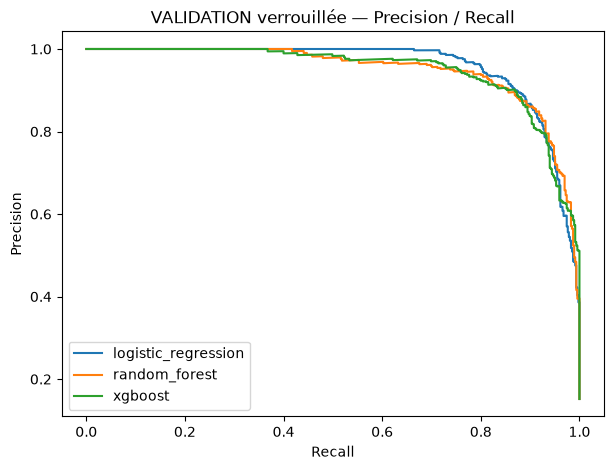

In [14]:
plt.figure(figsize=(7, 5))
for name, probability in validation_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_val, probability)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("VALIDATION verrouillée — Precision / Recall")
plt.legend()
plt.show()


### Analyse du résultat

Les courbes sont proches et confirment une bonne séparation globale. Leur lecture doit rester complémentaire au seuil opérationnel : une courbe favorable ne garantit pas le coût minimal au point de décision choisi.


## Conclusion

Le modèle n'est pas choisi parce qu'il est le plus complexe. La décision combine :
- respect des guardrails ;
- coût métier ;
- PR-AUC / ROC-AUC / calibration ;
- validation sur des moteurs jamais vus pendant le fit.
